# Aggregation vs dynamic programming vs Bertsekas vs Chen

All 51 catalogue models, default dimensions, shared value-error target.
Use a kernel with `mdpforge` installed; from the repository root: `python -m pip install -e ".[notebooks,maze]"`.
Each trial has a 60-second limit. Heatmap values are speedups relative to VI (higher is faster); `FAIL` includes errors, imprecise results and timeouts.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from mdpforge import Benchmark

SEED = 0
np.random.seed(SEED)
random.seed(SEED)
bench = Benchmark(default_solvers=False)

In [2]:
bench.add_mdp("access_control")
bench.add_mdp("acrobot")
bench.add_mdp("admission")
bench.add_mdp("ambulance")
bench.add_mdp("ambulance_relocation")
bench.add_mdp("barto")
bench.add_mdp("block")
bench.add_mdp("blocks_world")
bench.add_mdp("car_rental")
bench.add_mdp("cartpole")
bench.add_mdp("chain_walk")
bench.add_mdp("cliff")
bench.add_mdp("dam")
bench.add_mdp("elevator")
bench.add_mdp("forest")
bench.add_mdp("frozen")
bench.add_mdp("gambler")
bench.add_mdp("garnet")
bench.add_mdp("hexagonal_grid_soccer")
bench.add_mdp("impatience")
bench.add_mdp("inventory")
bench.add_mdp("inventory_leadtime")
bench.add_mdp("local_perception_grid_world")
bench.add_mdp("lqr")
bench.add_mdp("m_maze")
bench.add_mdp("maintenance")
bench.add_mdp("maze_backtrack")
bench.add_mdp("maze_prims")
bench.add_mdp("maze_wilson")
bench.add_mdp("mountain")
bench.add_mdp("ninerooms")
bench.add_mdp("office_world")
bench.add_mdp("oil")
bench.add_mdp("oil_discovery")
bench.add_mdp("option_pricing")
bench.add_mdp("peg_solitaire")
bench.add_mdp("queue_network")
bench.add_mdp("random_walk")
bench.add_mdp("replacement")
bench.add_mdp("rooms")
bench.add_mdp("schoolboy")
bench.add_mdp("sutton")
bench.add_mdp("swim")
bench.add_mdp("sysadmin")
bench.add_mdp("tandem")
bench.add_mdp("tandem_choice")
bench.add_mdp("taxi")
bench.add_mdp("tictactoe")
bench.add_mdp("unichain")
bench.add_mdp("windgrid")
bench.add_mdp("wumpus_world");

In [3]:
# Aggregation
bench.add_solver("aggregated_vi")
bench.add_solver("aggregated_qvi")
bench.add_solver("aggregated_mpi")

# Classical dynamic programming
bench.add_solver("mdpforge_vi")
bench.add_solver("mdpforge_mpi")

bench.add_solver("bertsekas_pi")
bench.add_solver("chen_td");

In [4]:
results = bench.run(
    discount=0.99, precision=1e-3, repeats=1, seed=SEED,
    verbose=True, timeout=60,
)

20_2_access_control / aggregated_vi [1/1]: success (0.002 s)
20_2_access_control / aggregated_qvi [1/1]: success (0.002 s)
20_2_access_control / aggregated_mpi [1/1]: success (0.005 s)
20_2_access_control / mdpforge_vi [1/1]: success (0.016 s)
20_2_access_control / mdpforge_mpi [1/1]: success (0.041 s)
20_2_access_control / bertsekas_pi [1/1]: success (0.011 s)
20_2_access_control / chen_td [1/1]: success (0.059 s)
257_3_acrobot / aggregated_vi [1/1]: success (0.032 s)
257_3_acrobot / aggregated_qvi [1/1]: success (0.031 s)
257_3_acrobot / aggregated_mpi [1/1]: success (0.024 s)
257_3_acrobot / mdpforge_vi [1/1]: success (0.027 s)
257_3_acrobot / mdpforge_mpi [1/1]: success (0.043 s)
257_3_acrobot / bertsekas_pi [1/1]: success (0.006 s)
257_3_acrobot / chen_td [1/1]: success (0.081 s)
108_2_admission_control / aggregated_vi [1/1]: success (0.003 s)
108_2_admission_control / aggregated_qvi [1/1]: success (0.002 s)
108_2_admission_control / aggregated_mpi [1/1]: success (0.005 s)
108_2_a

In [5]:
df = pd.DataFrame(results)
display(pd.crosstab(df["solver"], df["status"]))
display(df.loc[df["status"] != "success",
               ["model", "solver", "status", "error_bound", "error"]])

status,success
solver,
aggregated_mpi,51
aggregated_qvi,51
aggregated_vi,51
bertsekas_pi,51
chen_td,51
mdpforge_mpi,51
mdpforge_vi,51


,model,solver,status,error_bound,error


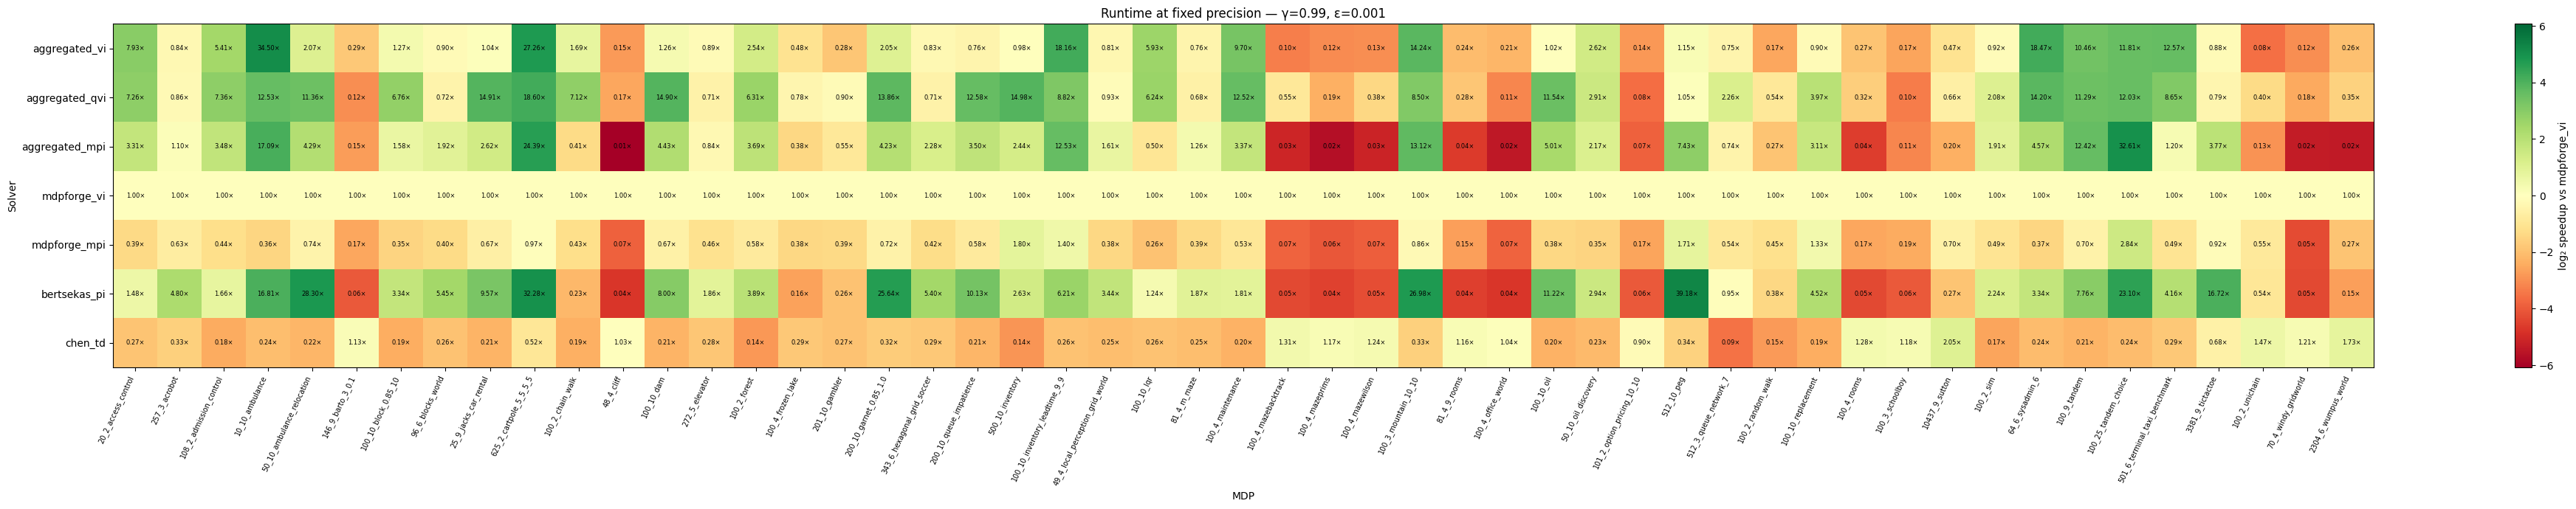

In [6]:
figure, axes = plt.subplots(figsize=(40, 7))
bench.plot_heat(reference="mdpforge_vi", ax=axes, show=False)
axes.tick_params(axis="x", labelsize=7, labelrotation=65)
for label in axes.texts:
    label.set_fontsize(6)
figure.tight_layout()
plt.show()